In [15]:
import cv2
import os
import numpy as np

dataset_path = "images"
os.makedirs(dataset_path, exist_ok=True)

for person_id in range(1, 4):
    person_folder = os.path.join(dataset_path, f"personne{person_id}")
    os.makedirs(person_folder, exist_ok=True)
    for img_id in range(1, 6):
        img = np.zeros((100, 100, 3), dtype=np.uint8)  # fond noir
        start = 10 * img_id
        cv2.rectangle(img, (start, start), (start+50, start+50), (255,255,255), -1)  # carré blanc
        img_path = os.path.join(person_folder, f"{img_id}.jpg")
        cv2.imwrite(img_path, img)

print("Mini-dataset créé : 3 personnes × 5 images")

Mini-dataset créé : 3 personnes × 5 images


In [20]:
import cv2
import numpy as np
import os

class FaceRecognitionPCA:
    def __init__(self, k):
        self.k = k
        self.face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
        self.mean_face = None
        self.eigenfaces = None
        self.training_projections = []
        self.labels = []
        self.X = None

    # Détection du visage
    def detect_face(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = self.face_cascade.detectMultiScale(gray, 1.3, 5)
        for (x, y, w, h) in faces:
            face = gray[y:y+h, x:x+w]
            face = cv2.resize(face, (100, 100))
            return face, (x, y, w, h)
        face = cv2.resize(gray, (100, 100))
        return face, None

    # Charger le dataset
    def prepare_training_set(self, folder_path):
        X = []
        for file in sorted(os.listdir(folder_path)):
            if not file.lower().endswith((".jpg", ".jpeg", ".png", ".pgm", ".bmp")):
                continue
            path = os.path.join(folder_path, file)
            img = cv2.imread(path)
            if img is None:
                continue
            face, _ = self.detect_face(img)
            if face is not None:
                X.append(face.flatten().astype(np.float64))
                self.labels.append(os.path.splitext(file)[0])
                print(f"  Chargé : {file} → label = {os.path.splitext(file)[0]}")
        self.X = np.array(X)
        print(f"[Dataset] {len(X)} visages chargés.")

    # Calcul PCA
    def compute_pca(self):
        self.mean_face = np.mean(self.X, axis=0)
        A = self.X - self.mean_face
        C = np.dot(A, A.T) / len(A)
        eigenvalues, eigenvectors_compact = np.linalg.eigh(C)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvectors_compact = eigenvectors_compact[:, idx]
        eigenvectors_full = np.dot(A.T, eigenvectors_compact)
        for i in range(eigenvectors_full.shape[1]):
            norm = np.linalg.norm(eigenvectors_full[:, i])
            if norm > 0:
                eigenvectors_full[:, i] /= norm
        k = min(self.k, len(self.X) - 1)
        self.eigenfaces = eigenvectors_full[:, :k]
        self.training_projections = [np.dot(face, self.eigenfaces) for face in A]
        print(f"[PCA] k={k} composantes calculées.")

    # Projection
    def project(self, face_vector):
        face_centered = face_vector.astype(np.float64) - self.mean_face
        return np.dot(face_centered, self.eigenfaces)

    # Reconnaissance
    def recognize(self, image_path, threshold):
        img = cv2.imread(image_path)
        if img is None:
            print(f"Image introuvable : {image_path}")
            return
        face, rect = self.detect_face(img)
        if face is None:
            print("Aucun visage détecté.")
            return
        face_vector = face.flatten()
        test_proj = self.project(face_vector)
        min_dist = float("inf")
        identity = None
        for i, train_proj in enumerate(self.training_projections):
            dist = np.linalg.norm(test_proj - train_proj)
            if dist < min_dist:
                min_dist = dist
                identity = self.labels[i]
        decision = "Match" if min_dist < threshold else "No Match"
        return identity, min_dist, decision, rect, img

In [21]:
import matplotlib.pyplot as plt

def show_image(img, identity, dist, decision, rect):
    color = (0, 255, 0) if decision == "Match" else (255, 0, 0)
    if rect is not None:
        x, y, w, h = rect
        cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
        cv2.putText(img, f"{identity}", (x, y-30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        cv2.putText(img, f"d={dist:.0f}", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        cv2.putText(img, decision, (x, y+h+25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

  Chargé : 1.jpg → label = 1
  Chargé : 2.jpg → label = 2
  Chargé : 3.jpg → label = 3
  Chargé : 4.jpg → label = 4
  Chargé : 5.jpg → label = 5
[Dataset] 5 visages chargés.
  Chargé : 1.jpg → label = 1
  Chargé : 2.jpg → label = 2
  Chargé : 3.jpg → label = 3
  Chargé : 4.jpg → label = 4
  Chargé : 5.jpg → label = 5
[Dataset] 5 visages chargés.
  Chargé : 1.jpg → label = 1
  Chargé : 2.jpg → label = 2
  Chargé : 3.jpg → label = 3
  Chargé : 4.jpg → label = 4
  Chargé : 5.jpg → label = 5
[Dataset] 5 visages chargés.
[PCA] k=2 composantes calculées.
Distance minimale : 0.00
Identité prédite  : 1
Décision          : Match


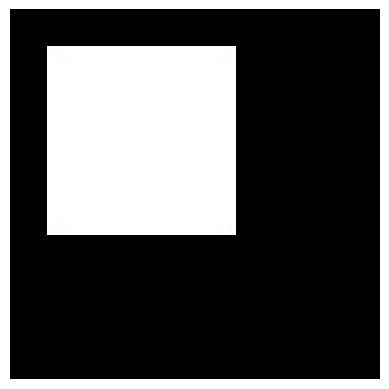

In [22]:
k = 2
threshold = 3000
model = FaceRecognitionPCA(k)

# Charger le mini-dataset
for person_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, person_folder)
    model.prepare_training_set(full_path)

# Calcul PCA
model.compute_pca()

# Image test
test_image = "images/personne1/1.jpg"
result = model.recognize(test_image, threshold)
if result is not None:
    identity, dist, decision, rect, img = result
    print(f"Distance minimale : {dist:.2f}")
    print(f"Identité prédite  : {identity}")
    print(f"Décision          : {decision}")
    show_image(img, identity, dist, decision, rect)